# 08 - Defect Classification

This notebook trains a classifier for defect type prediction.

The anomaly detector answers:

**Is this image good or defective?**

The classifier answers:

**If it is defective, what type of defect is it?**

## Classes

We classify images into four labels:

- `good`
- `broken_large`
- `broken_small`
- `contamination`

For the final app, the pipeline will be:

```text
image -> PaDiM anomaly detector -> good/defective + heatmap
      -> defect classifier -> defect type
      -> severity scoring
```

## Method

Because the labeled defect dataset is small, we use a practical transfer-learning approach:

1. Use pretrained ResNet18 as a frozen feature extractor.
2. Extract one embedding vector per image.
3. Train a scikit-learn Logistic Regression classifier.
4. Evaluate on a stratified holdout split.
5. Save the classifier as `models/defect_classifier.pkl`.

This is a good professional MVP approach for small labeled datasets.

In [1]:
from pathlib import Path
import json
import sys

import cv2
import matplotlib.pyplot as plt
import pandas as pd
import torch
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from ml.classifier import (
    LABEL_ORDER,
    build_resnet18_feature_extractor,
    load_classifier_bundle,
    predict_defect_type,
    train_defect_classifier,
)
from ml.dataset_loader import load_bottle_dataframe

MODEL_PATH = PROJECT_ROOT / "models" / "defect_classifier.pkl"
REPORT_DIR = PROJECT_ROOT / "outputs" / "reports"
CHART_DIR = PROJECT_ROOT / "outputs" / "charts"

REPORT_DIR.mkdir(parents=True, exist_ok=True)
CHART_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Classifier output:", MODEL_PATH)

Project root: C:\Users\HP\Desktop\springboard\visioninspect-ai
Classifier output: C:\Users\HP\Desktop\springboard\visioninspect-ai\models\defect_classifier.pkl


## GPU Check

Feature extraction can use the GPU. The scikit-learn classifier itself runs on CPU.

In [2]:
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


## Load Dataset

Use the dataset loader from `ml/dataset_loader.py`.

In [3]:
dataset_df = load_bottle_dataframe()
classification_df = dataset_df[dataset_df["label"].isin(LABEL_ORDER)].copy().reset_index(drop=True)

print("Total records:", len(classification_df))
display(classification_df.groupby("label").size().reset_index(name="count"))

classification_df.head()

Total records: 292


,label,count
0,broken_large,20
1,broken_small,22
2,contamination,21
3,good,229


,split,label,target,target_name,is_defective,image_path,mask_path,width,height,channels
0,train,good,0,good,False,C:\Users\HP\Desktop\springboard\visioninspect-...,NaN,900,900,3
1,train,good,0,good,False,C:\Users\HP\Desktop\springboard\visioninspect-...,NaN,900,900,3
2,train,good,0,good,False,C:\Users\HP\Desktop\springboard\visioninspect-...,NaN,900,900,3
3,train,good,0,good,False,C:\Users\HP\Desktop\springboard\visioninspect-...,NaN,900,900,3
4,train,good,0,good,False,C:\Users\HP\Desktop\springboard\visioninspect-...,NaN,900,900,3


## Visualize Class Distribution

The dataset is imbalanced because there are many more good images than defect images.

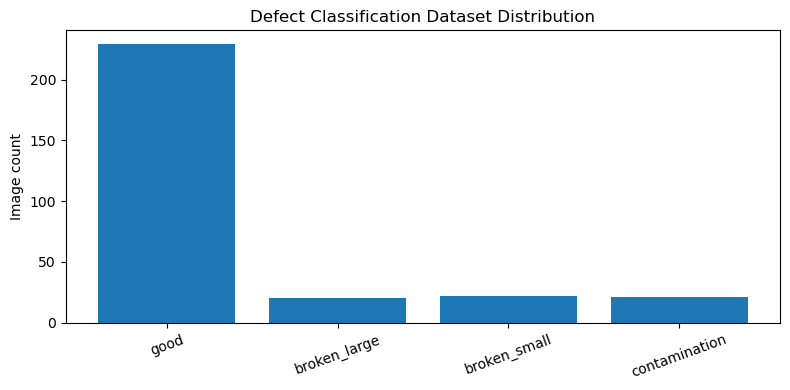

In [4]:
class_counts = classification_df.groupby("label").size().reindex(LABEL_ORDER).fillna(0)

plt.figure(figsize=(8, 4))
plt.bar(class_counts.index, class_counts.values)
plt.title("Defect Classification Dataset Distribution")
plt.ylabel("Image count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Stratified Train/Evaluation Split

A stratified split keeps all classes represented in both training and evaluation.

In [5]:
train_preview_df, eval_preview_df = train_test_split(
    classification_df,
    test_size=0.30,
    stratify=classification_df["label"],
    random_state=42,
)

print("Train preview size:", len(train_preview_df))
print("Eval preview size:", len(eval_preview_df))

display(train_preview_df.groupby("label").size().reset_index(name="train_count"))
display(eval_preview_df.groupby("label").size().reset_index(name="eval_count"))

Train preview size: 204
Eval preview size: 88


,label,train_count
0,broken_large,14
1,broken_small,15
2,contamination,15
3,good,160


,label,eval_count
0,broken_large,6
1,broken_small,7
2,contamination,6
3,good,69


## Train Classifier

This step extracts ResNet18 features and trains the scikit-learn classifier.

The first run may download ResNet18 ImageNet weights.

In [6]:
training_result = train_defect_classifier(
    classification_df,
    output_path=MODEL_PATH,
    test_size=0.30,
    random_state=42,
    batch_size=16,
)

metrics = training_result["metrics"]
train_df = training_result["train_df"]
eval_df = training_result["eval_df"].copy()
y_eval = training_result["y_eval"]
y_pred = training_result["y_pred"]

print("Saved classifier:", training_result["output_path"])
print("Accuracy:", metrics["accuracy"])
print("Train size:", metrics["train_size"])
print("Eval size:", metrics["eval_size"])

Saved classifier: C:\Users\HP\Desktop\springboard\visioninspect-ai\models\defect_classifier.pkl
Accuracy: 0.9318
Train size: 204
Eval size: 88


## Classification Report

This shows precision, recall, and F1-score per class.

In [7]:
report = classification_report(
    y_eval,
    y_pred,
    labels=metrics["labels"],
    zero_division=0,
)

print(report)

report_df = pd.DataFrame(metrics["classification_report"]).transpose()
report_df

               precision    recall  f1-score   support

         good       0.97      1.00      0.99        69
 broken_large       0.67      0.67      0.67         6
 broken_small       0.71      0.71      0.71         7
contamination       1.00      0.67      0.80         6

     accuracy                           0.93        88
    macro avg       0.84      0.76      0.79        88
 weighted avg       0.93      0.93      0.93        88



,precision,recall,f1-score,support
good,0.971831,1.000000,0.985714,69.000000
broken_large,0.666667,0.666667,0.666667,6.000000
broken_small,0.714286,0.714286,0.714286,7.000000
contamination,1.000000,0.666667,0.800000,6.000000
accuracy,0.931818,0.931818,0.931818,0.931818
macro avg,0.838196,0.761905,0.791667,88.000000
weighted avg,0.932458,0.931818,0.929708,88.000000


## Confusion Matrix

Rows are true labels. Columns are predicted labels.

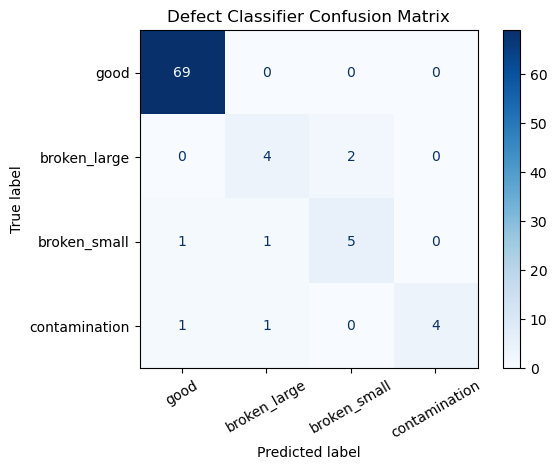

Saved confusion matrix: C:\Users\HP\Desktop\springboard\visioninspect-ai\outputs\charts\defect_classifier_confusion_matrix.png


In [8]:
ConfusionMatrixDisplay.from_predictions(
    y_eval,
    y_pred,
    labels=metrics["labels"],
    xticks_rotation=30,
    cmap="Blues",
)
plt.title("Defect Classifier Confusion Matrix")
plt.tight_layout()
confusion_matrix_path = CHART_DIR / "defect_classifier_confusion_matrix.png"
plt.savefig(confusion_matrix_path, dpi=160)
plt.show()

print("Saved confusion matrix:", confusion_matrix_path)

## Save Metrics And Predictions

These files will be used later in documentation and reporting.

In [9]:
metrics_path = REPORT_DIR / "defect_classifier_metrics.json"
predictions_path = REPORT_DIR / "defect_classifier_eval_predictions.csv"

eval_df["predicted_label"] = y_pred
eval_df["is_correct"] = eval_df["label"] == eval_df["predicted_label"]

with metrics_path.open("w", encoding="utf-8") as file:
    json.dump(metrics, file, indent=2)

eval_df.to_csv(predictions_path, index=False)

print("Saved metrics:", metrics_path)
print("Saved predictions:", predictions_path)

Saved metrics: C:\Users\HP\Desktop\springboard\visioninspect-ai\outputs\reports\defect_classifier_metrics.json
Saved predictions: C:\Users\HP\Desktop\springboard\visioninspect-ai\outputs\reports\defect_classifier_eval_predictions.csv


## Inspect Prediction Examples

Visual inspection helps catch label or data issues.

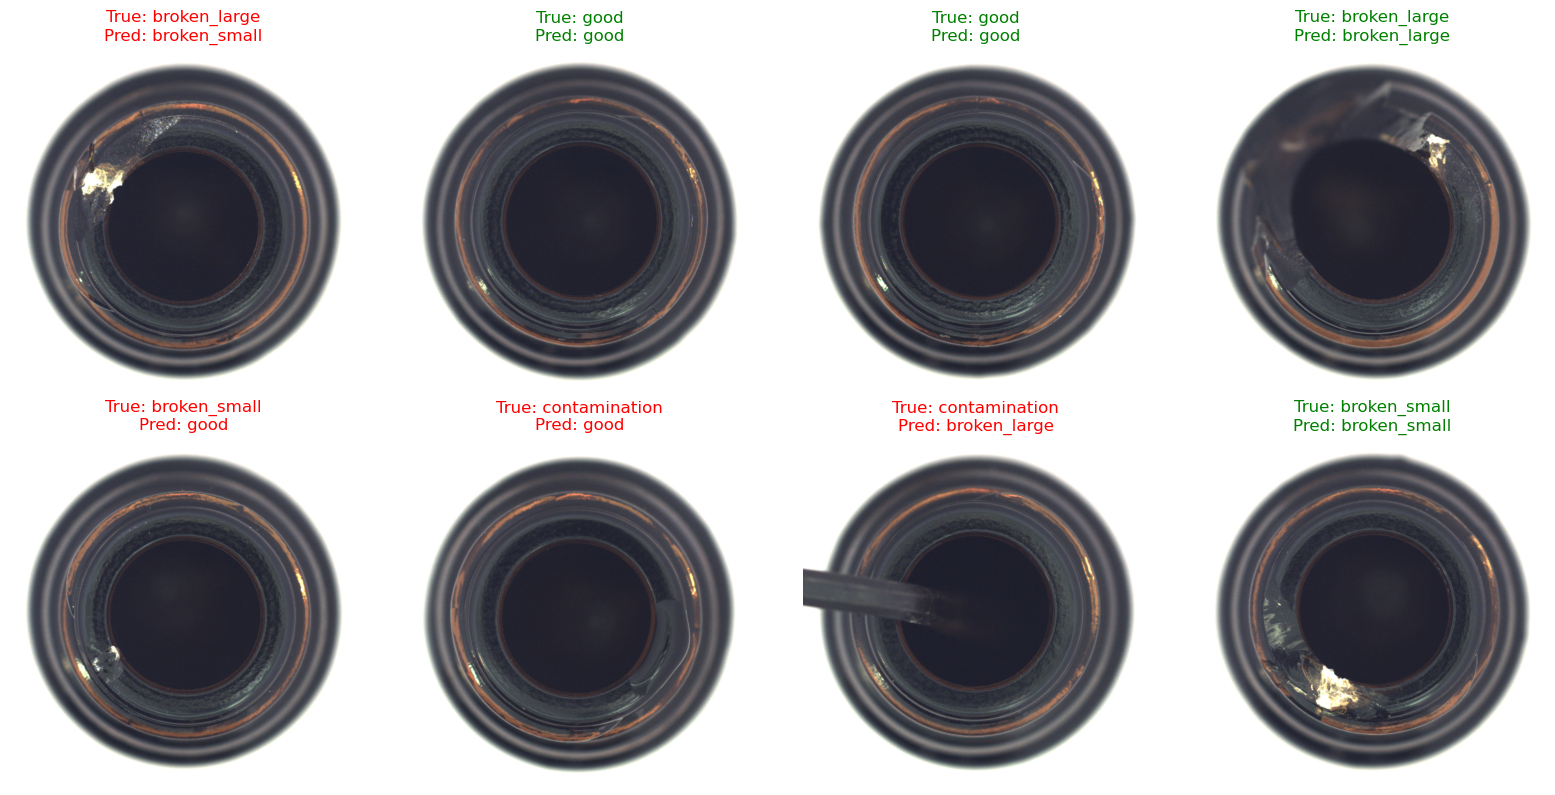

In [10]:
def read_rgb(path):
    image_bgr = cv2.imread(str(path))
    if image_bgr is None:
        raise FileNotFoundError(path)
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


examples = eval_df.groupby("label").head(2).reset_index(drop=True)

cols = min(4, len(examples))
rows = (len(examples) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

for ax, (_, row) in zip(axes, examples.iterrows()):
    ax.imshow(read_rgb(row["image_path"]))
    title = f"True: {row['label']}\nPred: {row['predicted_label']}"
    ax.set_title(title, color="green" if row["is_correct"] else "red")
    ax.axis("off")

for ax in axes[len(examples):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Test Saved Classifier Bundle

Now load the saved `.pkl` file and predict one image. This proves the backend can later load the same artifact.

In [11]:
classifier_bundle = load_classifier_bundle(MODEL_PATH)
sample_row = eval_df.iloc[0]
prediction = predict_defect_type(sample_row["image_path"], classifier_bundle)

print("Image:", sample_row["image_path"])
print("True label:", sample_row["label"])
prediction

Image: C:\Users\HP\Desktop\springboard\visioninspect-ai\data\raw\mvtec_anomaly_detection\bottle\test\broken_large\004.png
True label: broken_large


{'defect_type': 'broken_small',
 'confidence': 0.9988,
 'class_probabilities': {'broken_large': 0.0011650471078679756,
  'broken_small': 0.9988301238186329,
  'contamination': 2.615399990076817e-06,
  'good': 2.213673508960352e-06}}

## Update Model Metadata

The anomaly model metadata already exists. Here we add classifier artifact details.

In [12]:
metadata_path = PROJECT_ROOT / "models" / "model_metadata.json"

if metadata_path.exists():
    with metadata_path.open("r", encoding="utf-8") as file:
        metadata = json.load(file)
else:
    metadata = {"project": "VisionInspect AI"}

metadata["defect_classifier"] = {
    "model_type": "ResNet18 features + Logistic Regression",
    "artifact_path": str(MODEL_PATH),
    "labels": metrics["labels"],
    "accuracy": metrics["accuracy"],
    "train_size": metrics["train_size"],
    "eval_size": metrics["eval_size"],
    "feature_extractor": metrics["feature_extractor"],
}

with metadata_path.open("w", encoding="utf-8") as file:
    json.dump(metadata, file, indent=2)

print("Updated metadata:", metadata_path)
metadata["defect_classifier"]

Updated metadata: C:\Users\HP\Desktop\springboard\visioninspect-ai\models\model_metadata.json


{'model_type': 'ResNet18 features + Logistic Regression',
 'artifact_path': 'C:\\Users\\HP\\Desktop\\springboard\\visioninspect-ai\\models\\defect_classifier.pkl',
 'labels': ['good', 'broken_large', 'broken_small', 'contamination'],
 'accuracy': 0.9318,
 'train_size': 204,
 'eval_size': 88,
 'feature_extractor': 'resnet18_imagenet1k_v1'}

## Limitations

- The labeled defect classes are small: around 20 images per defect type.
- This classifier is suitable for a professional MVP/demo, but production should use more client-specific labeled examples.
- The anomaly detector remains the main quality-inspection model; the classifier adds defect type labels.

## Summary

You trained and saved a defect classification model:

- frozen ResNet18 ImageNet feature extractor
- Logistic Regression classifier
- four classes: good, broken_large, broken_small, contamination
- saved classifier bundle to `models/defect_classifier.pkl`
- saved metrics and predictions to `outputs/reports/`
- updated `models/model_metadata.json`

Next notebook: `09_severity_scoring.ipynb`.